In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv("employee_burnout_dataset_1000_records.csv")

df.head()

,employee_id,age,years_experience,weekly_work_hours,meetings_per_week,emails_sent_per_day,projects_handled,remote_days_per_month,sleep_hours,stress_level,exercise_hours_week,sick_leaves_year,productivity_score,burnout_risk_score
0,1,50,29,66,6,148,7,9,6.3,9,2.6,1,80,9.57
1,2,36,28,51,18,195,3,6,7.9,2,1.6,13,77,0.00
2,3,29,28,34,6,194,3,7,7.0,7,3.6,1,65,0.00
3,4,42,29,31,5,13,1,5,7.3,6,2.5,9,89,0.00
4,5,40,15,56,23,144,3,0,9.0,5,6.8,10,41,9.60


In [3]:
print("Shape of Dataset:", df.shape)
print("\nColumns:")
print(df.columns)

df.info()

Shape of Dataset: (1000, 14)

Columns:
Index(['employee_id', 'age', 'years_experience', 'weekly_work_hours',
       'meetings_per_week', 'emails_sent_per_day', 'projects_handled',
       'remote_days_per_month', 'sleep_hours', 'stress_level',
       'exercise_hours_week', 'sick_leaves_year', 'productivity_score',
       'burnout_risk_score'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            1000 non-null   int64  
 1   age                    1000 non-null   int64  
 2   years_experience       1000 non-null   int64  
 3   weekly_work_hours      1000 non-null   int64  
 4   meetings_per_week      1000 non-null   int64  
 5   emails_sent_per_day    1000 non-null   int64  
 6   projects_handled       1000 non-null   int64  
 7   remote_days_per_month  1000 non-null   int64  
 8   sleep_hours     

In [4]:
print(df.isnull().sum())


employee_id              0
age                      0
years_experience         0
weekly_work_hours        0
meetings_per_week        0
emails_sent_per_day      0
projects_handled         0
remote_days_per_month    0
sleep_hours              0
stress_level             0
exercise_hours_week      0
sick_leaves_year         0
productivity_score       0
burnout_risk_score       0
dtype: int64


In [5]:
df.describe()

,employee_id,age,years_experience,weekly_work_hours,meetings_per_week,emails_sent_per_day,projects_handled,remote_days_per_month,sleep_hours,stress_level,exercise_hours_week,sick_leaves_year,productivity_score,burnout_risk_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.947000,17.201000,52.457000,13.149000,108.796000,5.065000,9.593000,6.484000,5.601000,5.126200,7.336000,69.908000,6.565830
std,288.819436,11.160858,10.200424,12.906538,6.695942,54.945804,2.535982,5.748425,1.467357,3.009461,2.913424,4.270989,17.345559,9.458972
min,1.000000,22.000000,0.000000,30.000000,2.000000,10.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000,40.000000,0.000000
25%,250.750000,31.000000,8.000000,41.000000,7.000000,63.000000,3.000000,5.000000,5.200000,3.000000,2.600000,4.000000,55.000000,0.000000
50%,500.500000,42.000000,17.000000,52.000000,13.000000,111.000000,5.000000,10.000000,6.500000,6.000000,5.200000,7.000000,70.000000,0.145000
75%,750.250000,50.000000,26.000000,64.000000,19.000000,157.000000,7.000000,15.000000,7.700000,8.000000,7.700000,11.000000,85.000000,11.425000
max,1000.000000,59.000000,34.000000,74.000000,24.000000,199.000000,9.000000,19.000000,9.000000,10.000000,10.000000,14.000000,99.000000,51.780000


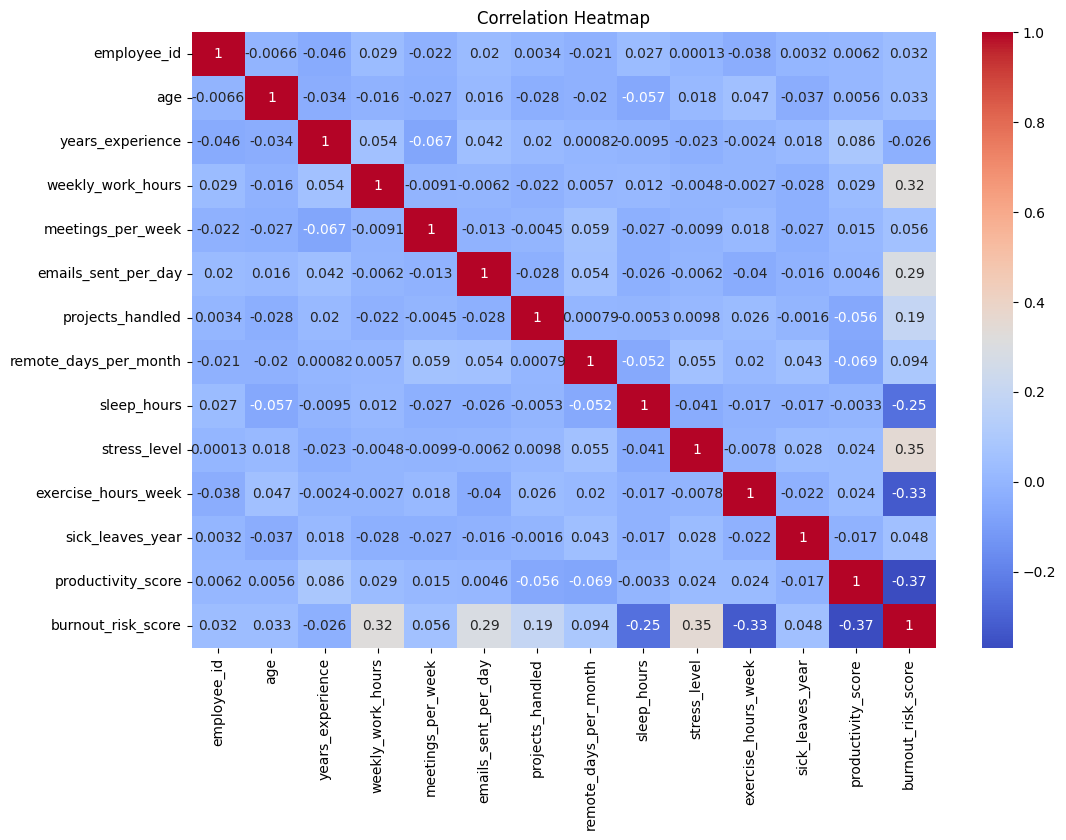

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

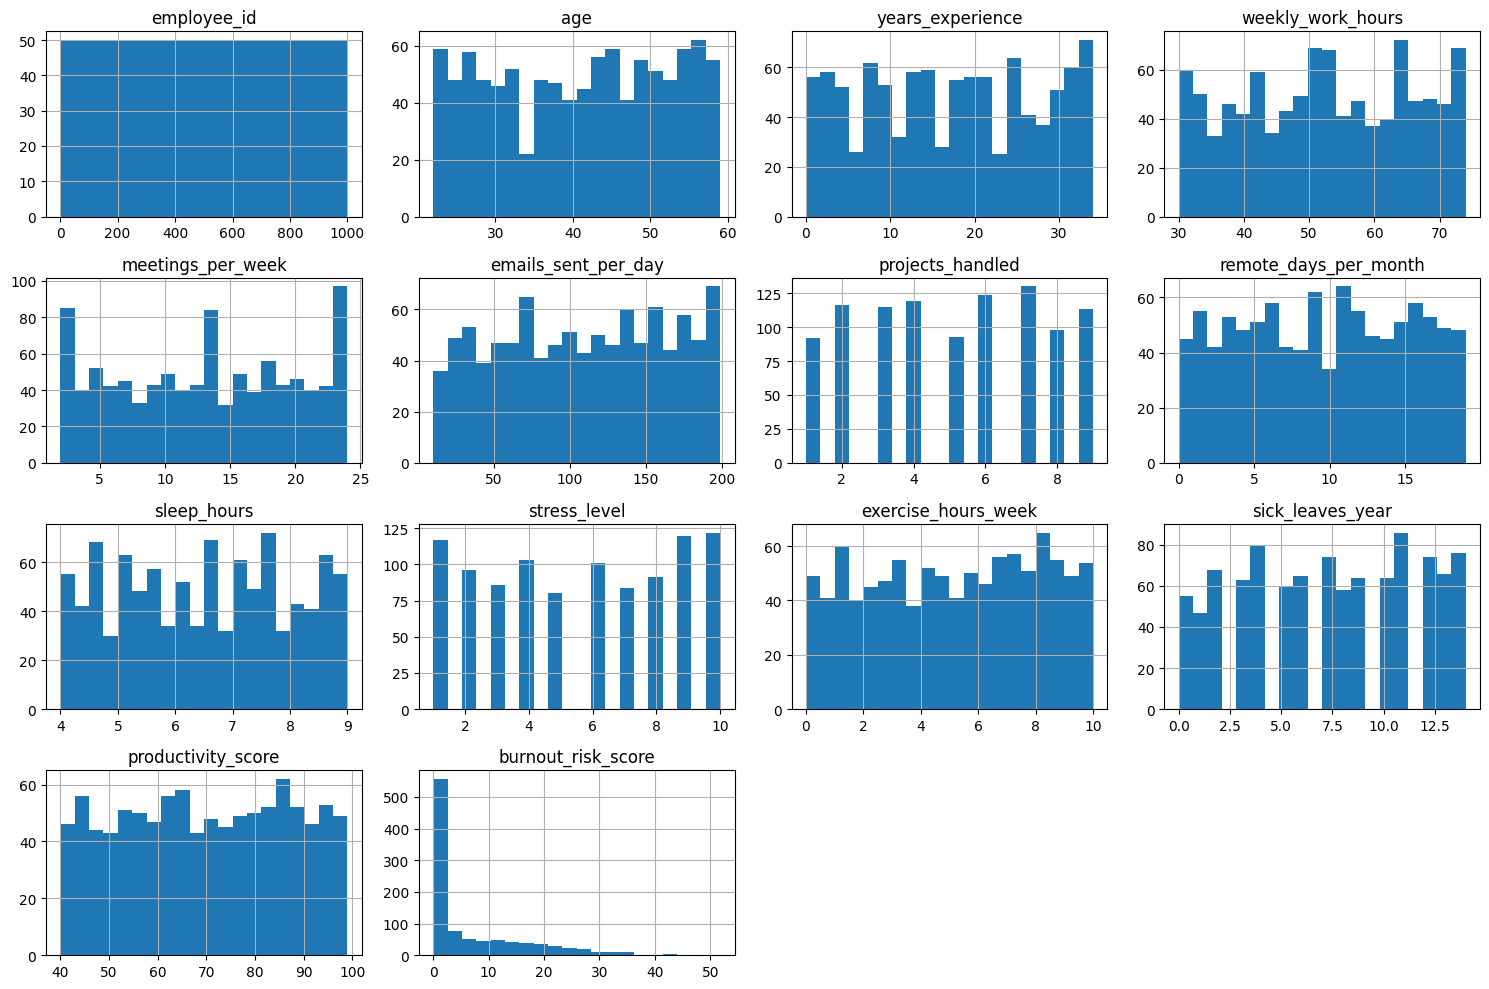

In [7]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

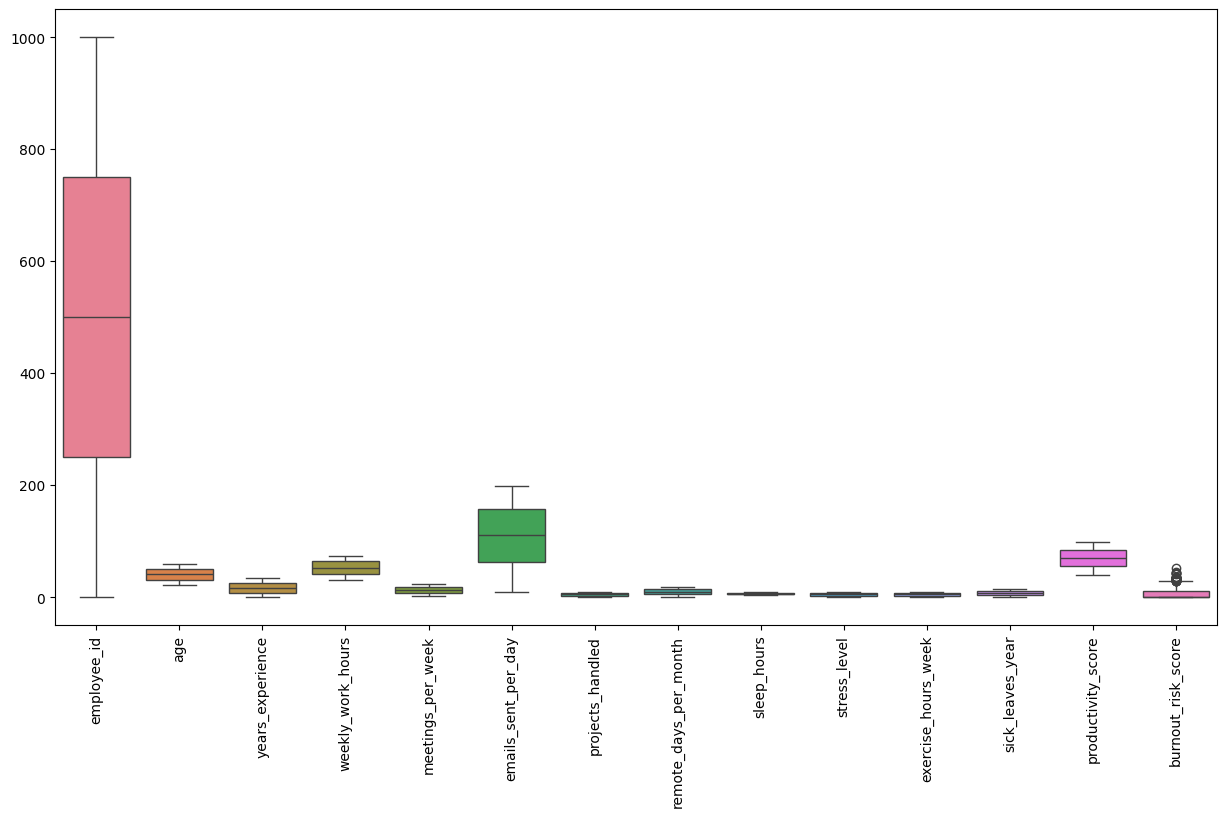

In [8]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

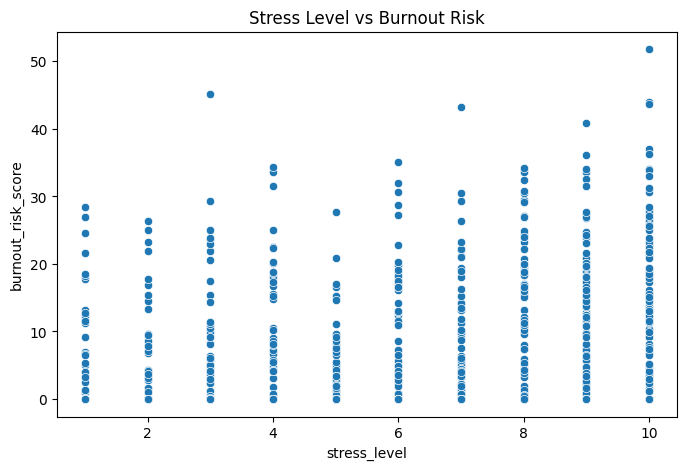

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='stress_level', y='burnout_risk_score', data=df)
plt.title("Stress Level vs Burnout Risk")
plt.show()

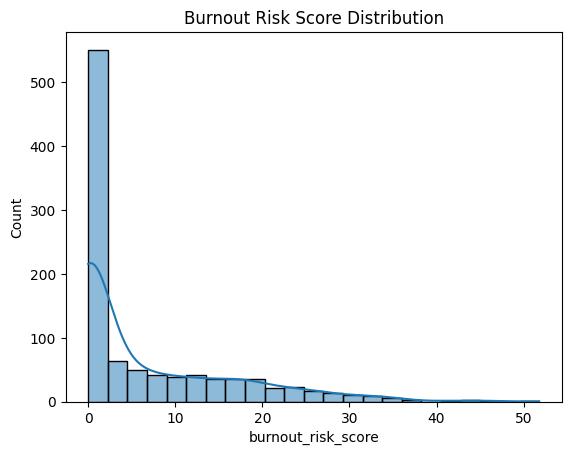

In [10]:
sns.histplot(df['burnout_risk_score'], kde=True)
plt.title("Burnout Risk Score Distribution")
plt.show()

In [11]:
df = df.drop("employee_id", axis=1)

df.head()

,age,years_experience,weekly_work_hours,meetings_per_week,emails_sent_per_day,projects_handled,remote_days_per_month,sleep_hours,stress_level,exercise_hours_week,sick_leaves_year,productivity_score,burnout_risk_score
0,50,29,66,6,148,7,9,6.3,9,2.6,1,80,9.57
1,36,28,51,18,195,3,6,7.9,2,1.6,13,77,0.00
2,29,28,34,6,194,3,7,7.0,7,3.6,1,65,0.00
3,42,29,31,5,13,1,5,7.3,6,2.5,9,89,0.00
4,40,15,56,23,144,3,0,9.0,5,6.8,10,41,9.60


In [12]:
X = df.drop("burnout_risk_score", axis=1)
y = df["burnout_risk_score"]

print(X.shape)
print(y.shape)

(1000, 12)
(1000,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 12)
Testing Data: (200, 12)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [15]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[12.14576843 -2.25126331  6.38473746  6.71335176 13.42426657]


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 4.649168905239442
MSE : 34.01820669220266
RMSE: 5.832512896874096
R2 Score: 0.6147494731514096


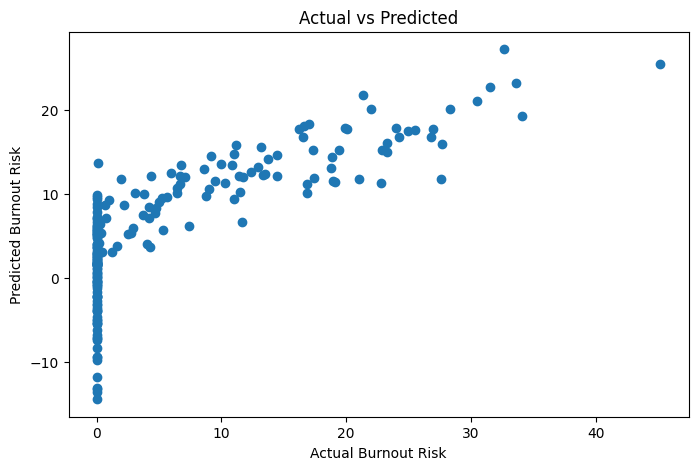

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Burnout Risk")
plt.ylabel("Predicted Burnout Risk")
plt.title("Actual vs Predicted")
plt.show()

In [18]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
8,stress_level,1.104058
5,projects_handled,0.713070
2,weekly_work_hours,0.255077
10,sick_leaves_year,0.105400
3,meetings_per_week,0.088769
4,emails_sent_per_day,0.048611
6,remote_days_per_month,0.036438
0,age,0.031162
1,years_experience,-0.004441
11,productivity_score,-0.209546


In [19]:
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
print(coefficients)

                  Feature  Coefficient
8            stress_level     1.104058
5        projects_handled     0.713070
2       weekly_work_hours     0.255077
10       sick_leaves_year     0.105400
3       meetings_per_week     0.088769
4     emails_sent_per_day     0.048611
6   remote_days_per_month     0.036438
0                     age     0.031162
1        years_experience    -0.004441
11     productivity_score    -0.209546
9     exercise_hours_week    -1.043501
7             sleep_hours    -1.582428


Business Insights

1. Stress Level has the strongest positive impact on burnout risk.
2. Employees handling more projects are more likely to experience burnout.
3. Longer weekly working hours increase burnout risk.
4. More sleep hours reduce burnout risk.
5. Regular exercise significantly reduces burnout risk.
6. Higher productivity is associated with lower burnout risk.

In [20]:
avg_hours = df['weekly_work_hours'].mean()

reduction = avg_hours * 0.10

impact = reduction * coefficients[
    coefficients['Feature']=='weekly_work_hours'
]['Coefficient'].values[0]

print("Estimated Burnout Reduction:", impact)

Estimated Burnout Reduction: 1.338056347485694


In [21]:
sleep_coef = coefficients[
    coefficients['Feature']=='sleep_hours'
]['Coefficient'].values[0]

print("Burnout Change:", sleep_coef)

Burnout Change: -1.5824278040073123


In [22]:
exercise_coef = coefficients[
    coefficients['Feature']=='exercise_hours_week'
]['Coefficient'].values[0]

print("Burnout Change:", exercise_coef * 3)

Burnout Change: -3.1305023208107396


Recommendations

• Monitor employees with high stress levels.
• Reduce excessive workload and overtime.
• Encourage healthy sleeping habits.
• Promote exercise and wellness programs.
• Distribute projects evenly among employees.
• Conduct periodic burnout risk assessments.